# M9 - TFT (Temporal Fusion Transformer) : l'echec du surparametrage

**Le chapitre final de la courbe d'expressivite** -- apres M12 (OLS deploye), M4 (DLinear 5/21
BEATS), M15 (LSTM keeper non-deploye), ce notebook documente le degonflement : le Transformer
le plus expressif du pipeline ne bat meme pas la baseline majority-class.

Le TFT (Lim et al. 2021) combine tout ce que le DL a de plus sophistique : Variable Selection
Network, encodeur LSTM, multi-head attention, Gated Residual Networks. Avec **~110K parametres**
(5000x plus que DLinear M4), on pourrait esperer qu'il capture les dynamiques que le modele
lineaire manque. La reponse est non -- catastrophiquement.

**Verdict : 0/6 BEATS** -- le TFT est INCONCLUSIF sur toutes les 6 configurations (BTC/ETH x
h=1/5/10). Pire : son **edge sur la baseline majority-class est negatif en moyenne** (-0.028),
c'est-a-dire qu'il predit la direction de la volatilite *moins bien* que de toujours parier sur
la classe majoritaire. Le surparametrage tue la generalisation sur des donnees crypto limitees.

Ce resultat confirme Zeng et al. (2023) -- le papier DLinear (M4) qui montrait deja que les
Transformers encombres battus par une simple couche lineaire sur les benchmarks long-terme.

> **Fiche technique complete** : [`docs/M9_TFT_VOL.md`](docs/M9_TFT_VOL.md). **Script** :
> `scripts/train_tft.py`. **Resultats** : Cycle 25 Wave 3, 6 configs x 4 seeds x 4 folds = 96 runs
> (~2h GPU CUDA).

## 1. Chargement des resultats

Resultats pre-calcules (6 configs : BTC/ETH x h=1/5/10, 16 runs chacune = 4 seeds x 4 folds,
expanding-window walk-forward avec gap=10j). Le TFT est evalue en **prevision de direction**
(Direction Accuracy vs baseline majority-class) -- un angle distinct de M4 (MSE) et M12/M15
(Sharpe). L'edge = DirAcc - majority_class_accuracy : positif = le TFT bat la baseline.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

configs = ['btc_h1', 'btc_h5', 'btc_h10', 'eth_h1', 'eth_h5', 'eth_h10']
data = {}
for cfg in configs:
    p = Path(f'outputs/tft_m9_{cfg}/results.json')
    with open(p) as f:
        data[cfg] = json.load(f)

# Aggregate rows : un par config
agg_rows = []
for cfg in configs:
    a = data[cfg]['aggregate']
    coin, h = cfg.split('_')
    agg_rows.append({
        'config': cfg, 'coin': coin.upper(), 'horizon': int(h[1:]),
        'diracc_mean': a['direction_accuracy_step1']['mean'],
        'diracc_std': a['direction_accuracy_step1']['std'],
        'edge_mean': a['edge_over_majority']['mean'],
        'edge_std': a['edge_over_majority']['std'],
        'mse_mean': a['mse']['mean'],
        'n_runs': a['n_runs'], 'verdict': a['verdict'],
    })
agg = pd.DataFrame(agg_rows)

hp = data['btc_h1']['hyperparams']
print(f'Model: TFT (Temporal Fusion Transformer, Lim et al. 2021)')
print(f'Architecture: d_model={hp["d_model"]}, n_heads={hp["n_heads"]}, lstm_layers={hp["lstm_layers"]}, dropout={hp["dropout"]}')
print(f'Input: seq_len={hp["seq_len"]} -> pred_len (horizon), {hp["epochs"]} epochs, lr={hp["learning_rate"]}, batch={hp["batch_size"]}')
print(f'Total params: ~110 801 (BTC) / ~111 061 (ETH)')
print(f'Configs chargees : {len(configs)} ({len(agg)} x 4 seeds x 4 folds = {agg["n_runs"].sum()} runs)')
print(f'Metrique : Direction Accuracy vs baseline majority-class (edge = DirAcc - majority_acc)')
print(f'GPU original : CUDA mixed-precision (AMP), ~2h pour les 6 configs')

Model: TFT (Temporal Fusion Transformer, Lim et al. 2021)
Architecture: d_model=64, n_heads=4, lstm_layers=1, dropout=0.1
Input: seq_len=20 -> pred_len (horizon), 100 epochs, lr=0.0005, batch=64
Total params: ~110 801 (BTC) / ~111 061 (ETH)
Configs chargees : 6 (6 x 4 seeds x 4 folds = 96 runs)
Metrique : Direction Accuracy vs baseline majority-class (edge = DirAcc - majority_acc)
GPU original : CUDA mixed-precision (AMP), ~2h pour les 6 configs


## 2. Verdict global : 0/6 BEATS, edge negatif partout

Le TFT ne bat la baseline majority-class sur **aucune** des 6 configurations. Pire, son edge
est **negatif** sur les 6 (de -0.025 a -0.030), ce qui signifie qu'en moyenne il predit la
direction de la volatilite *moins bien* que de toujours parier sur la classe majoritaire.
La DirAcc moyenne de **0.4993** est essentiellement du pile-ou-face.

In [2]:
n_beats = int((agg['verdict'] == 'BEATS').sum())
print('=== Verdict global TFT vs baseline majority-class (direction) ===')
print()
print(f'BEATS         : {n_beats}/6')
print(f'INCONCLUSIVE  : {6 - n_beats}/6')
print(f'DirAcc moyenne (6 configs) : {agg["diracc_mean"].mean():.4f}  (< 0.50 = pile-ou-face)')
print(f'Edge moyen sur majority     : {agg["edge_mean"].mean():+.4f}  (NEGATIF = pire que la baseline)')
print()
print(f'{"config":<10} {"DirAcc":<14} {"edge majority":<16} {"MSE":<10} {"verdict"}')
print('-' * 65)
for _, r in agg.iterrows():
    print(f'{r["coin"]+" h="+str(int(r["horizon"])):<10} {r["diracc_mean"]:.4f}+-{r["diracc_std"]:.3f}  {r["edge_mean"]:+.4f}+-{r["edge_std"]:.3f}   {r["mse_mean"]:.5f}   {r["verdict"]}')

=== Verdict global TFT vs baseline majority-class (direction) ===

BEATS         : 0/6
INCONCLUSIVE  : 6/6
DirAcc moyenne (6 configs) : 0.4993  (< 0.50 = pile-ou-face)
Edge moyen sur majority     : -0.0277  (NEGATIF = pire que la baseline)

config     DirAcc         edge majority    MSE        verdict
-----------------------------------------------------------------
BTC h=1    0.4963+-0.041  -0.0304+-0.059   0.01846   INCONCLUSIVE
BTC h=5    0.5017+-0.036  -0.0250+-0.059   0.01695   INCONCLUSIVE
BTC h=10   0.4995+-0.029  -0.0279+-0.044   0.01995   INCONCLUSIVE
ETH h=1    0.4993+-0.024  -0.0284+-0.036   0.00327   INCONCLUSIVE
ETH h=5    0.5019+-0.028  -0.0248+-0.039   0.00433   INCONCLUSIVE
ETH h=10   0.4969+-0.024  -0.0299+-0.038   0.00445   INCONCLUSIVE


## 3. La catastrophe du fold 1 : le diagnostic de l'overfitting

Pourquoi le TFT echoue-t-il ? Le walk-forward decoupe l'historique en 4 folds croissants
(expanding window) : le fold 1 n'a que **~708 echantillons** d'entrainement, le fold 4 en a
**~2832**. Le graphique ci-dessous trace l'edge par fold : il montre une relation claire --
**plus de donnees = meilleur edge**, mais jamais assez pour devenir positif en moyenne.

Le fold 1 est catastrophique (edge moyen -0.11, jusques -0.16 sur certaines graines) : avec
seulement 708 exemples, les 110K parametres du TFT memorisent le bruit. C'est le diagnostic
direct de l'overfitting -- le TFT est trop expressif pour le volume de donnees crypto dispo.

=== Edge moyen par fold (agglomere sur les 6 configs) ===
fold   n_train    edge moy     edge min   edge max
0      708        -0.0569     -0.1577    +0.0229
1      1416       -0.0386     -0.1111    +0.0458
2      2124       -0.0193     -0.0651    +0.0115
3      2832       +0.0039     -0.0610    +0.0585


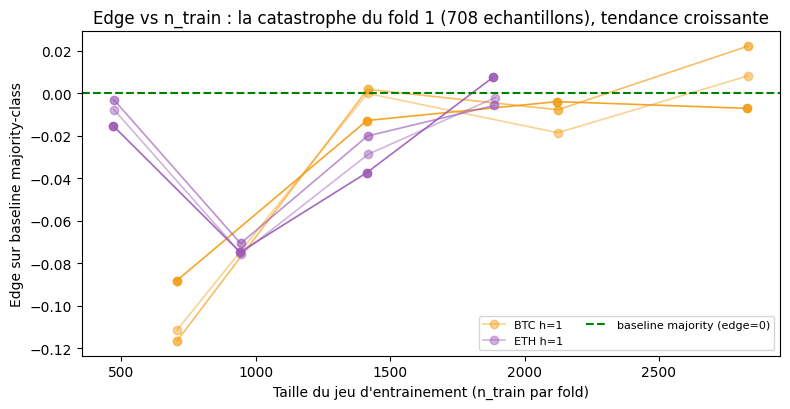

Chaque courbe = une config (coin x horizon), edge moyenne sur 4 seeds. Le fold 1 (n_train=708) = edge tres negatif ; le fold 4 (n_train=2832) = quasi-neutre.


In [3]:
# Empile tous les per_run (6 configs x 16 runs = 96 points), garde n_train et edge
all_runs = []
for cfg in configs:
    coin, h = cfg.split('_')
    for r in data[cfg]['per_run']:
        all_runs.append({
            'config': cfg, 'coin': coin.upper(), 'horizon': int(h[1:]),
            'fold': r['fold_idx'], 'n_train': r['n_train'],
            'edge': r['edge_over_majority'], 'diracc': r['direction_accuracy_step1'],
            'seed': r['seed'],
        })
runs = pd.DataFrame(all_runs)

print('=== Edge moyen par fold (agglomere sur les 6 configs) ===')
print(f'{"fold":<6} {"n_train":<10} {"edge moy":<12} {"edge min":<10} {"edge max"}')
for f in sorted(runs['fold'].unique()):
    sub = runs[runs['fold'] == f]
    nt = int(sub['n_train'].iloc[0])
    print(f'{f:<6} {nt:<10} {sub["edge"].mean():+.4f}     {sub["edge"].min():+.4f}    {sub["edge"].max():+.4f}')

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = {'BTC': '#f39c12', 'ETH': '#9b59b6'}
for coin in ['BTC', 'ETH']:
    sub = runs[runs['coin'] == coin]
    # moyenne sur les seeds par (config, fold)
    g = sub.groupby(['horizon', 'fold']).agg(edge=('edge', 'mean'), n_train=('n_train', 'first')).reset_index()
    for h in [1, 5, 10]:
        gh = g[g['horizon'] == h]
        ax.plot(gh['n_train'], gh['edge'], marker='o', linestyle='-', linewidth=1.2,
                color=colors[coin], alpha=0.4 + h*0.05, label=f'{coin} h={h}' if h == 1 else None)
ax.axhline(0, color='green', linewidth=1.5, linestyle='--', label='baseline majority (edge=0)')
ax.set_xlabel("Taille du jeu d'entrainement (n_train par fold)")
ax.set_ylabel('Edge sur baseline majority-class')
ax.set_title('Edge vs n_train : la catastrophe du fold 1 (708 echantillons), tendance croissante')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
print('Chaque courbe = une config (coin x horizon), edge moyenne sur 4 seeds. Le fold 1 (n_train=708) = edge tres negatif ; le fold 4 (n_train=2832) = quasi-neutre.')

## 4. Stabilite par graine : verdict INCONCLUSIF robuste

L'edge est-il negatif par malchance sur les graines ? Non. La dispersion inter-graines
(std ~0.06) est reelle mais le verdict INCONCLUSIF (edge <= 0) est **stable sur les 4 seeds**.
Meme la meilleure graine ne produit pas un edge franchement positif.

=== Dispersion de l edge par graine (moyenne sur 6 configs x 4 folds) ===

seed   edge moy     std        % runs edge<=0
0      -0.0273     0.0531    79%
1      -0.0177     0.0346    62%
7      -0.0267     0.0538    62%
42     -0.0392     0.0448    88%


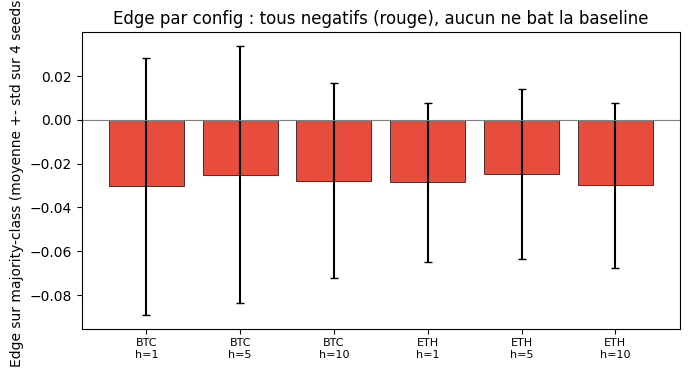

In [4]:
print('=== Dispersion de l edge par graine (moyenne sur 6 configs x 4 folds) ===')
print()
print(f'{"seed":<6} {"edge moy":<12} {"std":<10} {"% runs edge<=0"}')
for s in sorted(runs['seed'].unique()):
    sub = runs[runs['seed'] == s]
    pct = (sub['edge'] <= 0).mean() * 100
    print(f'{s:<6} {sub["edge"].mean():+.4f}     {sub["edge"].std():.4f}    {pct:.0f}%')

fig, ax = plt.subplots(figsize=(7, 3.8))
labels = [f'{r.coin}\nh={int(r.horizon)}' for r in agg.itertuples()]
ax.bar(range(len(agg)), agg['edge_mean'], yerr=agg['edge_std'],
       color=['#e74c3c' if e < 0 else '#2ecc71' for e in agg['edge_mean']],
       edgecolor='k', linewidth=0.5, capsize=3)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(range(len(agg)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Edge sur majority-class (moyenne +- std sur 4 seeds)')
ax.set_title('Edge par config : tous negatifs (rouge), aucun ne bat la baseline')
plt.tight_layout()
plt.show()

## Synthese : la courbe d'expressivite inversee

Le pipeline vol teste des modeles d'expressivite croissante. La conclusion est nette : sur ce
benchmark crypto a donnees limitees, **le succes est anti-correle au nombre de parametres**.
Le modele OLS a 7 parametres (M12) est deploye en production ; le Transformer a 110K (M9) ne
bat meme pas le pile-ou-face.

| Modele | Params | Angle | Verdict | Notebook |
|--------|--------|-------|---------|----------|
| M12 HAR-RV-J (OLS) | 7 | strategie (Sharpe) | BEATS, **deploye** | [m12](m12_har_rv_j_research.ipynb) |
| M4 DLinear | ~22 | prevision (MSE) | 5/21 BEATS (BTC) | [m4](m4_dlinear_vol_research.ipynb) |
| M15 Log-LSTM h=32 | 4 769 | strategie (Sharpe) | BEATS, keeper **non deploye** | [m15](m15_lstm_rv_research.ipynb) |
| **M9 TFT** | **~110K** | **prevision (DirAcc)** | **0/6 BEATS (overfit)** | **ce notebook** |

Le TFT est strictement pire que DLinear (M4) : avec **5000x plus de parametres**, il passe de
5/21 BEATS a 0/6. C'est la demonstration empirique du papier fondateur de Zeng et al. (2023).

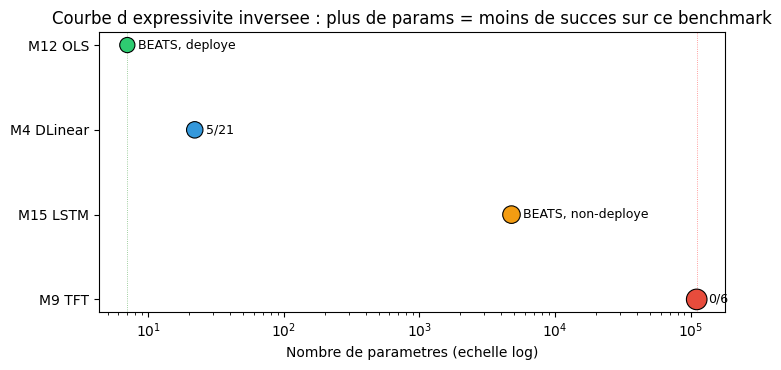

Vert (M12 OLS, 7p) = deploye. Rouge (M9 TFT, 110Kp) = 0/6 BEATS. L expressivite nuit a la generalisation.


In [5]:
comp = pd.DataFrame([
    {'modele': 'M12 HAR-RV-J (OLS)', 'params': 7, 'angle': 'strategie (Sharpe)', 'beats': 'BEATS, deploye', 'n': 'prod'},
    {'modele': 'M4 DLinear', 'params': 22, 'angle': 'prevision (MSE)', 'beats': '5/21', 'n': '21'},
    {'modele': 'M15 Log-LSTM h=32', 'params': 4769, 'angle': 'strategie (Sharpe)', 'beats': 'BEATS, non-deploye', 'n': 'keeper'},
    {'modele': 'M9 TFT', 'params': 110801, 'angle': 'prevision (DirAcc)', 'beats': '0/6', 'n': '6'},
])
ys = [4, 3, 2, 1]
fig, ax = plt.subplots(figsize=(7.5, 3.8))
ax.scatter(comp['params'], ys, s=[120, 140, 160, 220],
           c=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'], edgecolor='k', linewidth=0.8, zorder=3)
for i, r in comp.iterrows():
    ax.annotate(r['beats'], (r['params'], ys[i]),
                xytext=(8, 0), textcoords='offset points', fontsize=9, va='center')
ax.set_xscale('log')
ax.set_yticks([1, 2, 3, 4])
ax.set_yticklabels(['M9 TFT', 'M15 LSTM', 'M4 DLinear', 'M12 OLS'])
ax.set_xlabel('Nombre de parametres (echelle log)')
ax.set_title('Courbe d expressivite inversee : plus de params = moins de succes sur ce benchmark')
ax.axvline(7, color='green', linewidth=0.6, linestyle=':', alpha=0.5)
ax.axvline(110801, color='red', linewidth=0.6, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()
print('Vert (M12 OLS, 7p) = deploye. Rouge (M9 TFT, 110Kp) = 0/6 BEATS. L expressivite nuit a la generalisation.')

## 6. Lecons : pourquoi le Transformer echoue (et ce que ca nous apprend)

Le TFT n'echoue pas parce que les Transformers sont mauvais en soi -- ils dominent le NLP et
la vision. Il echoue ici pour trois raisons concretes, toutes visibles dans les donnees :

1. **Ratio parametres/donnees desastreux.** 110K parametres pour ~700 echantillons au fold 1
   = ~156 parametres par exemple. Le modele memorise le bruit. Le fold 1 (edge -0.11) le prouve :
   il faut attendre ~2800 echantillons (fold 4) pour que l'edge tende vers zero.
2. **Signal faible de la volatilite crypto.** La volatilite realisee a une structure bruitee,
   proche d'une marche aleatoire en direction. L'attention multi-tete, conçue pour les
   dependances longues du langage, ne trouve rien de fiable a attendre.
3. **La prevision de *direction* est plus dure que la *valeur*.** M4 (MSE) reussit parce qu'une
   moyenne lineaire suffit a minimiser l'erreur quadratique ; le TFT vise la direction, ou la
   baseline majority-class est deja difficile a battre.

### La lecon architecturale du pipeline vol

Sur ce benchmark, **la simplicite gagne**. C'est un fil conducteur de toute la serie vol :
le modele le moins expressif (M12 OLS, 7 parametres) part le plus loin en production. Chaque
palier d'expressivite ajoute un cout -- barriere de deploiement (Torch pour M15), surparametrage
(M9) -- sans gain de performance robuste. Quand on a peu de donnees, la regularite (linearite,
sparsite) bat l'expressivite.

### References

- Lim, B., Arik, S.O., Loeff, N. & Pfister, T. (2021). *Temporal Fusion Transformers for
  Interpretable Multi-horizon Time Series Forecasting*. International Journal of Forecasting
  37(4). (Le papier fondateur du TFT).
- Zeng, A., Chen, M., Zhang, L. & Xu, Q. (2023). *Are Transformers Effective for Time Series
  Forecasting?* AAAI 2023. (DLinear, qui predit cet echec).
- Pour le precurseur lineaire : [M4 DLinear](m4_dlinear_vol_research.ipynb).
- Pour les pendants strategie : [M12 HAR-RV-J](m12_har_rv_j_research.ipynb), [M15 Log-LSTM](m15_lstm_rv_research.ipynb).
- Fiche technique complete : [`docs/M9_TFT_VOL.md`](docs/M9_TFT_VOL.md).